# Assignment 3.1
Name:  
Date:

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 3.2.

In an exit poll of 1648 voters in the 2020 Senatorial election in Arizona, 51.5% said they voted
for Mark Kelly and 48.5% said they voted for Martha McSally

a) Suppose that actually 50% of the population voted for Kelly. If this exit poll had the
properties of a simple random sample, find the standard error of the sample proportion
voting for him.

b) Under the 50% presumption, are the results of the exit poll surprising? Why? Would you
be willing to predict the election outcome? Explain by (i) conducting a simulation; (ii)
using the value found in (a) for the standard error.

`(a) Your answer goes here`

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate random seed
rng = np.random.default_rng(73) # rng seed

# Sample size
n = 1648
# True population proportion
pi = 1/2

# a) =========== Find Standard error ===========
# Observed sample proportion
pi_hat_observed = 0.515

# Standard error (theoretical)
se = np.sqrt(pi* (1 - pi) / n)# OUtput
print("a) Find Standard Error:")
print(f"Standard Error (theoretical): {se:.5f}\nAbout {se*100:.3f} percentage points")



a) Find Standard Error:
Standard Error (theoretical): 0.01232
About 1.232 percentage points


`(b) Your answer goes here`


b) INTERPRETATION:
Standard Error (simulated): 0.01232
About 1.232 percentage points
Thus, theoretical and simulated are approximately the same.
Simulation correctly approximating the sample distribution.

If the true proportion is 0.5, then random sampling with n=1648 makes the 
sample proportion vary by about 0.01232.
The observed pi_hat = 0.515 is
0.015 above 0.50, which is
1.218 standard errors.
This is not surprising.
One-sided P(pi_hat >= 0.515 | pi=0.50) ≈ 0.114
Two-sided P(|pi_hat-0.50| >= 0.015)    ≈ 0.227
Conclusion: Not surprising under pi=0.50; weak evidence to predict winner from this alone.
In summary, If that fraction is large (say 10-15%), 
then observing 0.515 isn't surprising—it could easily happen by chance even in a tied race. That means you can't confidently predict Kelly wins.


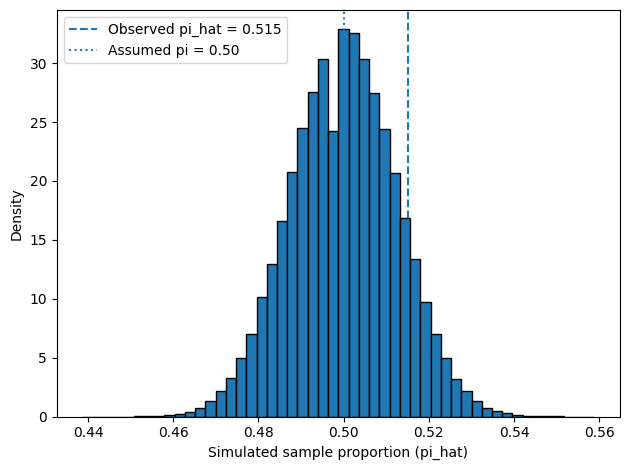

In [14]:
print("\nb) INTERPRETATION:")
# Standard Error (Simulated)
se_simulation = pi_hat.std(ddof=1)

# Simulation-based tail probabilities
p_one_sided = np.mean(pi_hat >= pi_hat_observed)
p_two_sided = np.mean(np.abs(pi_hat - pi) >= abs(pi_hat_observed - pi))

print(42*"=")
print(f"Standard Error (simulated): {se:.5f}\nAbout {se_simulation*100:.3f} percentage points")
print("Thus, theoretical and simulated are approximately the same.")
print("Simulation correctly approximating the sample distribution.")
print(
    f"\nIf the true proportion is {pi}, then random sampling with n={n} makes the \n"
    f"sample proportion vary by about {se:.5f}.\n"
    f"The observed pi_hat = {pi_hat_observed:.3f} is\n"
    f"{pi_hat_observed - pi:.3f} above 0.50, which is\n"
    f"{((pi_hat_observed - pi) / se):.3f} standard errors.\n"
    "This is not surprising."
)
print(f"One-sided P(pi_hat >= 0.515 | pi=0.50) ≈ {p_one_sided:.3f}")
print(f"Two-sided P(|pi_hat-0.50| >= 0.015)    ≈ {p_two_sided:.3f}")
print("Conclusion: Not surprising under pi=0.50; weak evidence to predict winner from this alone.")
print(42*"=")
print("""In summary, If that fraction is large (say 10-15%), 
then observing 0.515 isn't surprising—it could easily happen by chance even in a tied race. That means you can't confidently predict Kelly wins.""")

# Plotting results
plt.hist(pi_hat, bins=50, density=True, edgecolor="black")
plt.axvline(pi_hat_observed, linestyle="--", label="Observed pi_hat = 0.515")
plt.axvline(pi, linestyle=":", label="Assumed pi = 0.50")
plt.xlabel("Simulated sample proportion (pi_hat)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## Problem 3.3.

 The 49 students in a class at the University of Florida made blinded evaluations of pairs of
cola drinks. For the 49 comparisons of Coke and Pepsi, Coke was preferred 29 times. In the
population that this sample represents, is this strong evidence that a majority prefers Coke?
Use a simulation of a sampling distribution to answer.

`Your answer goes here`



For a sample size of 49, the presumed population proportion 0.5,
observed sample proportion 0.592, and 
simulated sample proportion 0.500, 
we get a (theoretical) standard error of 0.071,
and a simulated standard error of 0.071.
      

We observed 0.592 preferring COKE.
To assess whether this is strong evidence for the majority of the population
preferring coke, we assumed the 'no-majority' (50/50) scenario, where pi = 0.5 and
simulated many random samples of size 49.
This produced a sampling distribution for pi_hat under pi = 0.5. 
The simulated standard error of pi_hat was close to the theoretical value 
SE = 0.071, confirming the expected variability from sample to sampple.
      

How unusual the observed result is under pi=0.5, I calculated the proportion
of simulations with pi_hat >= 0.592.
The tail proportion was 0.126, meaning that if the population was
actually 50/50, results at least this favorable to coke would occur about
12.64% of the time via random sampling.
than half

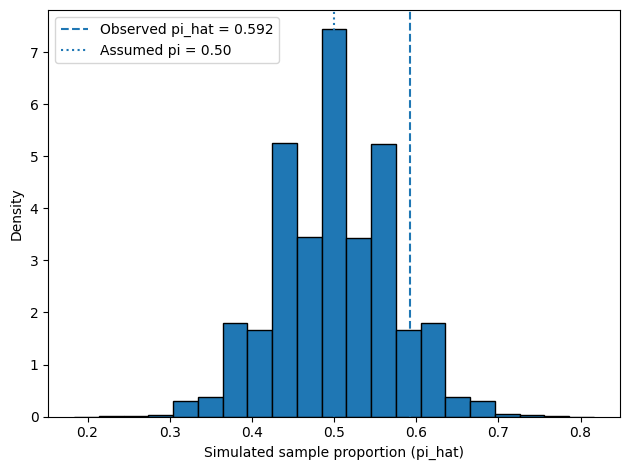

In [15]:
from math import ceil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Random seed
rng = np.random.default_rng(73)

# Sample space
n = 49

# Observed proportion for preferring coke
pi_hat_observed = 29 / n

# Assume: Binomial dist. and 50/50 for preferring coke
pi = 1/2

# Theoretical standard error
se = np.sqrt(pi * (1 - pi) / n)

# simulation
Y = rng.binomial(n, pi, size=int(1e6))

# Sample proportion
pi_hat = Y / n

# Sample proportion mean (simulated)
pi_hat_mew = pi_hat.mean()

# Simulated standard error
se_simulated = pi_hat.std(ddof=1)

# Simulation-based tail probabilities
p_one = np.mean(pi_hat >= pi_hat_observed)
p_two = np.mean(np.abs(pi_hat - pi) >= abs(pi_hat_observed - pi))

# Z-score method standard error
z = (pi_hat_observed - pi) / se

# Output values
print(f"""\n
For a sample size of {n}, the presumed population proportion {pi},
observed sample proportion {pi_hat_observed:.3f}, and 
simulated sample proportion {pi_hat_mew:.3f}, 
we get a (theoretical) standard error of {se:.3f},
and a simulated standard error of {se_simulated:.3f}.
      """)

# Interpretation
print(f"""
We observed {pi_hat_observed:.3f} preferring COKE.
To assess whether this is strong evidence for the majority of the population
preferring coke, we assumed the 'no-majority' (50/50) scenario, where pi = {pi} and
simulated many random samples of size {n}.
This produced a sampling distribution for pi_hat under pi = {pi}. 
The simulated standard error of pi_hat was close to the theoretical value 
SE = {se:.3f}, confirming the expected variability from sample to sampple.
      """)
print(f"""
How unusual the observed result is under pi={pi}, I calculated the proportion
of simulations with pi_hat >= {pi_hat_observed:.3f}.
The tail proportion was {p_one:.3f}, meaning that if the population was
actually 50/50, results at least this favorable to coke would occur about
{p_one*100:.2f}% of the time via random sampling.
than half of population prefers coke.
This happens about {p_one*100:.2f}% of the time under pi = {pi}, which is not
rare.\n
Also, the Z-score metho shows that it's about {z:.3f} standard erros above
{pi}.
      """)


# Plotting histogram
bins = ceil(1 + np.log2(len(Y)))
plt.hist(pi_hat, bins=bins, density=True, edgecolor="black")
plt.axvline(pi_hat_observed, linestyle="--", label=f"Observed pi_hat = {pi_hat_observed:.3f}")
plt.axvline(pi, linestyle=":", label="Assumed pi = 0.50")
plt.xlabel("Simulated sample proportion (pi_hat)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## Problem 3.5.

The example in Section 3.1.4 simulated sampling distributions of the sample mean to determine how precise $\bar{Y}$ for $n=25$ may estimate a population mean $\mu.$

a) Find the theoretical standard error of $\bar{Y}$ for the scenario values of $\sigma = 5$ and 8. How do they compare to the standard deviations of the 100,000 sample means in the simulations?

`Your answer goes here`

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# x range
x = np.arange(0, 60.01, 0.01)

# Sample size
n = 25

# a) Standard errors (theoretical)
mew = 20
sig1, sig2 = 5, 8
se1, se2 = sig1/np.sqrt(n), sig2/np.sqrt(n)

# Output
print(f"Theoretical Standard Errors are")
print(f"se1 = {se1:.3f}")
print(f"se2 = {se2:.3f}")

# Gamma parameters
shape1 = (mew / sig1) ** 2
scale1 = (sig1 ** 2) / mew
shape2 = (mew / sig2) ** 2
scale2 = (sig2 ** 2) / mew

print("Gamma parameters:")
print(f"Scenario 1: shape={shape1:.2f}, scale={scale1:.2f}")
print(f"Scenario 2: shape={shape2:.2f}, scale={scale2:.2f}\n")


Theoretical Standard Errors are
se1 = 1.000
se2 = 1.600
Gamma parameters:
Scenario 1: shape=16.00, scale=1.25
Scenario 2: shape=6.25, scale=3.20



b) In the first scenario, we chose $\sigma = 5$ under the belief that if $\mu = 20$, about 2/3 of the sample values would fall between `$`15 and `$`25. For the gamma distribution with $(\mu, \sigma) = (20,5),$ show that the actual probability between 15 and 25 is 0.688.

`Your answer goes here`

P(15 <= Y <= 25) = 0.688
Simulation results (100,000 sample means):
Scenario 1 mean(Ȳ): 20.004   SD(Ȳ): 0.997
Scenario 2 mean(Ȳ): 20.008   SD(Ȳ): 1.604

Comparison (theory vs simulation):
Scenario 1: theoretical SE=1.000 vs simulated SD(Ȳ)=0.997
Scenario 2: theoretical SE=1.600 vs simulated SD(Ȳ)=1.604

INTERPRETATION:

The simulated SDs of Y_bar are close to the theoretical SEs, 1.0, 1.6,
confirming the samplling distribution variablilty.
Scenario 2 has a larger spread because the standard deviation is larger, so
SE(Y) is larger.
      


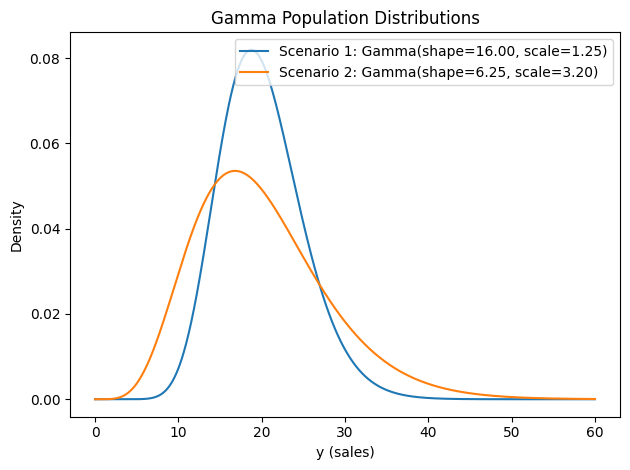

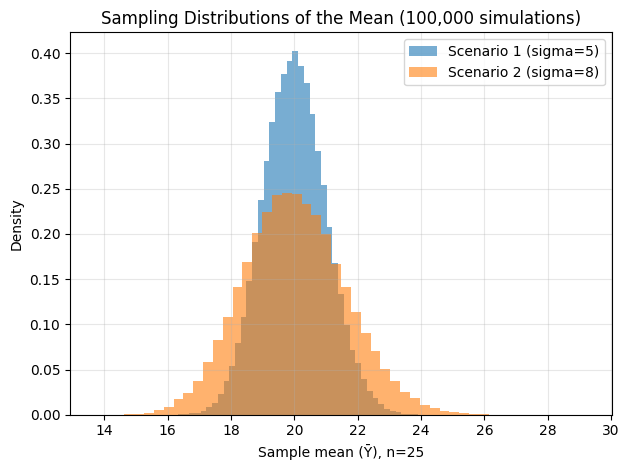

In [18]:
# ---- Simulation of sampling distribution of the mean ----
# Verifying P(15 =< Y <= 25) ~ 0.688
# P(15 <= Y <= 25) for Scenario 1
p = gamma.cdf(25, a=shape1, scale=scale1) - gamma.cdf(15, a=shape1, scale=scale1)
print(f"P(15 <= Y <= 25) = {p:.3f}")

# Random seed
rng = np.random.default_rng(73)
reps = int(1e5)

Y1 = rng.gamma(shape=shape1, scale=scale1, size=(reps, n))
Y2 = rng.gamma(shape=shape2, scale=scale2, size=(reps, n))

Y1mean = Y1.mean(axis=1)
Y2mean = Y2.mean(axis=1)

print("Simulation results (100,000 sample means):")
print(f"Scenario 1 mean(Ȳ): {Y1mean.mean():.3f}   SD(Ȳ): {Y1mean.std(ddof=1):.3f}")
print(f"Scenario 2 mean(Ȳ): {Y2mean.mean():.3f}   SD(Ȳ): {Y2mean.std(ddof=1):.3f}\n")

print("Comparison (theory vs simulation):")
print(f"Scenario 1: theoretical SE={se1:.3f} vs simulated SD(Ȳ)={Y1mean.std(ddof=1):.3f}")
print(f"Scenario 2: theoretical SE={se2:.3f} vs simulated SD(Ȳ)={Y2mean.std(ddof=1):.3f}")

# Interpretation
print(f"""
INTERPRETATION:\n
The simulated SDs of Y_bar are close to the theoretical SEs, {se1}, {se2},
confirming the samplling distribution variablilty.
Scenario 2 has a larger spread because the standard deviation is larger, so
SE(Y) is larger.
      """)

# Gamma PDFs
plt.plot(x, gamma.pdf(x, a=shape1, scale=scale1),
         label=f"Scenario 1: Gamma(shape={shape1:.2f}, scale={scale1:.2f})")
plt.plot(x, gamma.pdf(x, a=shape2, scale=scale2),
         label=f"Scenario 2: Gamma(shape={shape2:.2f}, scale={scale2:.2f})")
plt.xlabel("y (sales)")
plt.ylabel("Density")
plt.title("Gamma Population Distributions")
plt.legend()
plt.tight_layout()
plt.show()

# Histograms of sampling distributions (means)
plt.hist(Y1mean, bins=50, density=True, alpha=0.6, label="Scenario 1 (sigma=5)")
plt.hist(Y2mean, bins=50, density=True, alpha=0.6, label="Scenario 2 (sigma=8)")
plt.xlabel("Sample mean (Ȳ), n=25")
plt.ylabel("Density")
plt.title("Sampling Distributions of the Mean (100,000 simulations)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Problem 3.8.

Construct the sampling distribution of the sample proportion of heads, for flipping a balanced
coin (a) once; (b) twice; (c) three times; (d) four times. Describe how the shape changes
as the number of flips $n$ increases. What would happen if $n$ kept growing? Why?


`Your answer goes here`


n = 1 flips (balanced coin, p = 0.5)
------------------------------------------------------------
p-hat values: [0. 1.]
probabilities: [0.5 0.5]
Mean of p-hat: 0.50
SD (SE) of p-hat: 0.5000


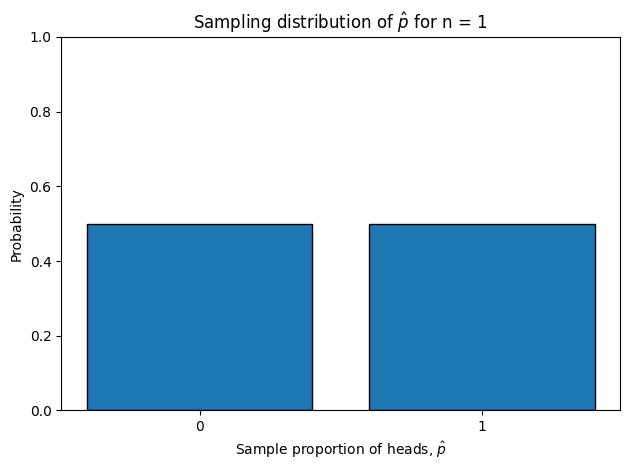


n = 2 flips (balanced coin, p = 0.5)
------------------------------------------------------------
p-hat values: [0.  0.5 1. ]
probabilities: [0.25 0.5  0.25]
Mean of p-hat: 0.50
SD (SE) of p-hat: 0.3536


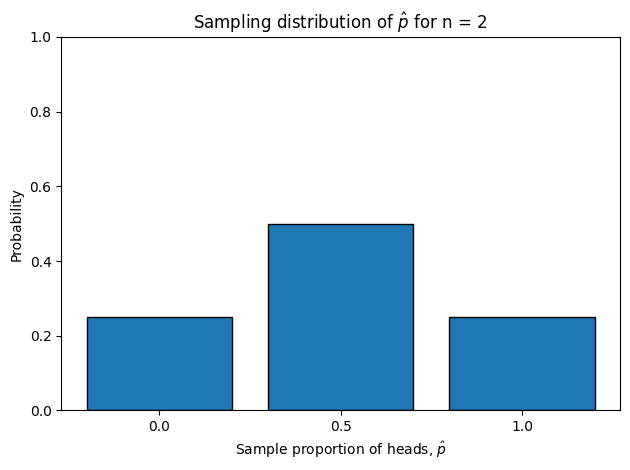


n = 3 flips (balanced coin, p = 0.5)
------------------------------------------------------------
p-hat values: [0.         0.33333333 0.66666667 1.        ]
probabilities: [0.125 0.375 0.375 0.125]
Mean of p-hat: 0.50
SD (SE) of p-hat: 0.2887


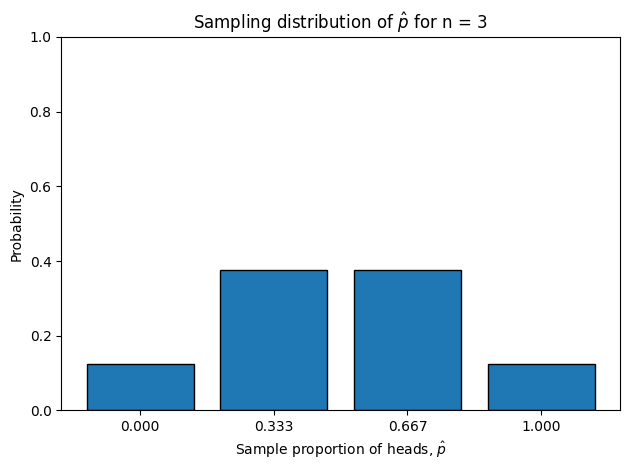


n = 4 flips (balanced coin, p = 0.5)
------------------------------------------------------------
p-hat values: [0.   0.25 0.5  0.75 1.  ]
probabilities: [0.0625 0.25   0.375  0.25   0.0625]
Mean of p-hat: 0.50
SD (SE) of p-hat: 0.2500


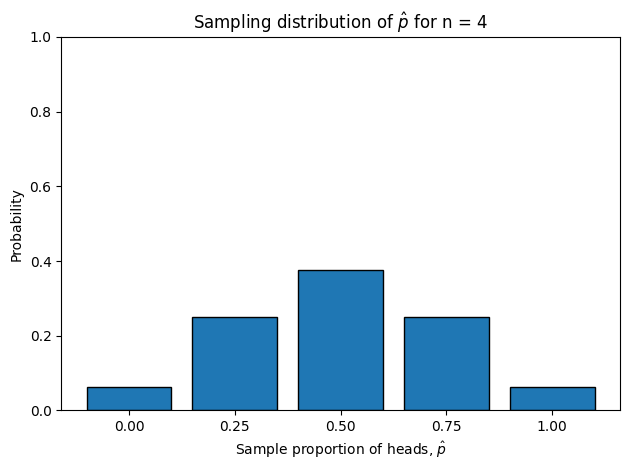


How variability changes with n (SE = sqrt(p(1-p)/n))
------------------------------------------------------------
n =  1: SE = 0.5000
n =  2: SE = 0.3536
n =  3: SE = 0.2887
n =  4: SE = 0.2500

For larger n, the shape of the sampling distribution becomes more bell shaped (Normal distribution) via the Central Limit Theorem.
      


In [20]:
from scipy.stats import binom, norm
from scipy.special import comb
import numpy as np
import matplotlib.pyplot as plt

def sampling_dist_phat(n, p=0.5):
    """
    Returns:
      phat_vals: array of possible p-hat values (0, 1/n, ..., 1)
      probs:     array of probabilities P(p-hat = k/n)
    """
    k = np.arange(n + 1)              # k = number of heads
    phat_vals = k / n                 # p-hat = k/n
    probs = np.array([comb(n, ki) * (p**ki) * ((1 - p)**(n - ki)) for ki in k])
    return phat_vals, probs


# a) - d) Sampling dists
ns = [1, 2, 3, 4]
p = 0.5

for n in ns:
    phat_vals, probs = sampling_dist_phat(n, p=p)

    # Print the distribution in a clean way
    print("\n" + "=" * 60)
    print(f"n = {n} flips (balanced coin, p = {p})")
    print("-" * 60)
    print("p-hat values:", phat_vals)
    print("probabilities:", np.round(probs, 4))

    # Theoretical mean and standard deviation of p-hat
    mu = p
    se = np.sqrt(p * (1 - p) / n)
    print(f"Mean of p-hat: {mu:.2f}")
    print(f"SD (SE) of p-hat: {se:.4f}")

    # Plot (bar chart)
    plt.figure()
    plt.bar(phat_vals, probs, width=0.8 * (1 / n), edgecolor="black")
    plt.xlabel("Sample proportion of heads, $\hat{p}$")
    plt.ylabel("Probability")
    plt.title(f"Sampling distribution of $\hat{{p}}$ for n = {n}")
    plt.xticks(phat_vals)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Summary
print("\n" + "=" * 60)
print("How variability changes with n (SE = sqrt(p(1-p)/n))")
print("-" * 60)
for n in ns:
    se = np.sqrt(p * (1 - p) / n)
    print(f"n = {n:>2}: SE = {se:.4f}")


# Interpretation
print("""
For larger n, the shape of the sampling distribution becomes more bell shaped (Normal distribution) via the Central Limit Theorem.
      """)


## Problem 3.13.

Simulate random sampling from a uniform population distribution with several $n$ values to
illustrate the Central Limit Theorem.

`Your answer goes here`

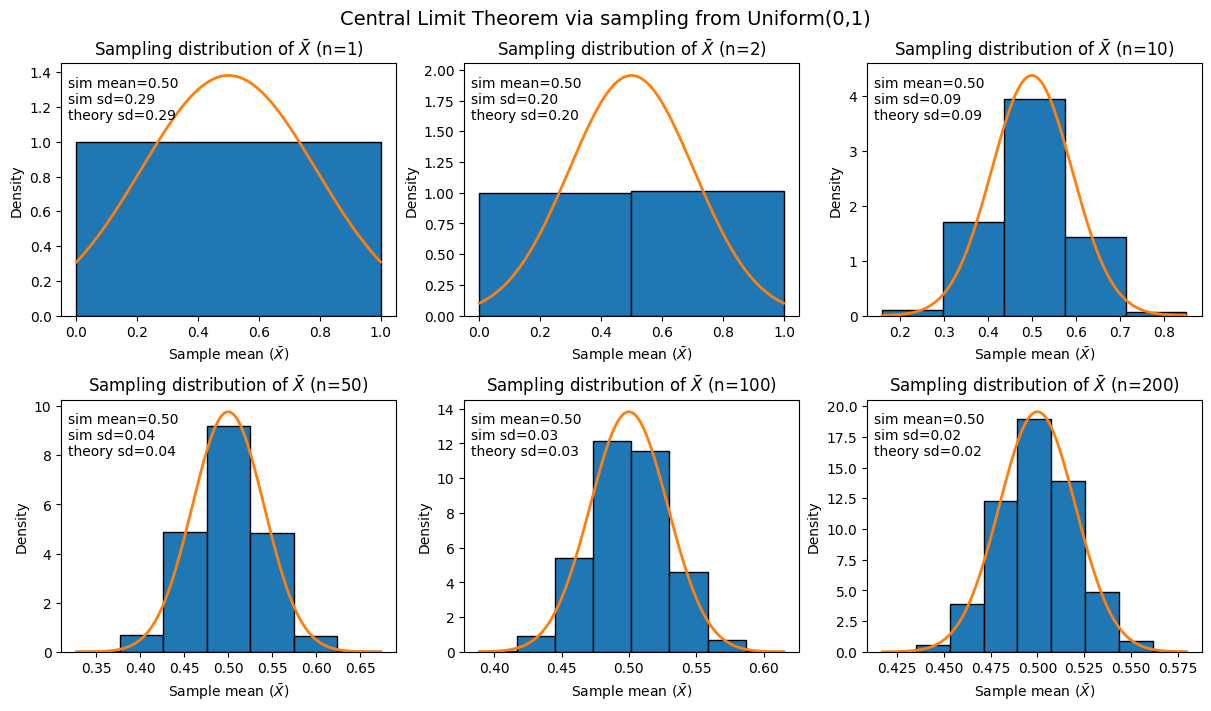

Population mean mew = 0.50
Population SD sigma = 0.29
CLT prediction: for large n, (X̄ - mew) / (sigma/sqrt(n)) ≈ N(0,1).

INTERPRETATION
f
As the sample size increases, the sampling distribution becomes more and more
symmetric (CLT).

The simulated mean of X_bar remains near the population mean of 1/2 for all n,
while the simulated standard deviation decreases at a rate of sigma /
sqrt(n), confirming the theoretical result.
      


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from scipy.stats import norm

# Uniform dist
a, b = 0, 1

# ======== Simewlation ========
n_vals = [1, 2, 10, 50, 100, 200]

# Random seed
rng = np.random.default_rng(73)

# population params
mew = (a+b)/2
# 12 comes from the variance
sig = (b - a) / np.sqrt(12)

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
#  convert a mewlti-dimensional array of Axes objects (subplots) returned by plt.subplots() into a one-dimensional flattened array or a list of axes.
axes = axes.ravel()

for ax, n in zip(axes, n_vals):
    sample_x = rng.uniform(a, b, size=(int(5e4), n)).mean(axis=1)

    # Normal approx via CLT
    se = sig / np.sqrt(n)
    grid = np.linspace(sample_x.min(), sample_x.max(), 400)
    pdf = norm.pdf(grid, loc=mew, scale=se)

    # Histogram via Sturge's Rule
    bins =  ceil(1 + np.log2(n))
    ax.hist(sample_x, bins=bins, density=True, edgecolor="black")
    ax.plot(grid, pdf, linewidth=2)
    ax.set_title(f"Sampling distribution of $\\bar{{X}}$ (n={n})")
    ax.set_xlabel("Sample mean ($\\bar{X}$)")
    ax.set_ylabel("Density")

    # Print quick numeric check (rounded to 2 decimals)
    ax.text(
        0.02, 0.95,
        f"sim mean={sample_x.mean():.2f}\n"
        f"sim sd={sample_x.std(ddof=1):.2f}\n"
        f"theory sd={se:.2f}",
        transform=ax.transAxes,
        va="top"
    )

plt.suptitle("Central Limit Theorem via sampling from Uniform(0,1)", fontsize=14)
plt.show()

print(f"Population mean mew = {mew:.2f}")
print(f"Population SD sigma = {sig:.2f}")
print("CLT prediction: for large n, (X̄ - mew) / (sigma/sqrt(n)) ≈ N(0,1).")

# Interpretation
print("\nINTERPRETATION")
print("=" * 60)
print("""f
As the sample size increases, the sampling distribution becomes more and more
symmetric (CLT).

The simulated mean of X_bar remains near the population mean of 1/2 for all n,
while the simulated standard deviation decreases at a rate of sigma /
sqrt(n), confirming the theoretical result.
      """)
print("=" * 60)


## Problem 3.14.

On each bet in a sequence of bets, you win 1 dollar with probability 0.50 and lose 1 dollar (i.e., win negative 1 dollar) with probability 0.50. Let $Y$ denote the total of your winnings and losings after 100 bets. Giving your reasoning, state the approximate distribution of $Y.$ 

`Your answer goes here`

In [23]:
import numpy as np

n_bets = 100
p_win = 1/2

# Possible outcomes
results = np.array([1, -1])
probs = np.array([p_win, 1 - p_win])

# Theoretical
mew = n_bets * (p_win * 1 + (1 - p_win) * (-1))
var = n_bets * 1
std = np.sqrt(var)

print("THEORETICAL RESULTS")
print("=" * 30)
print(f"Mean of Y: {mew}")
print(f"Variance of Y: {var}")
print(f"Standard Deviation of Y: {std}")
print("Approximate distribution: Y ~ Normal(0, 100)")

# Simulation
rng = np.random.default_rng(73)
n_sim = int(1e5)

# Generate random sample
X = rng.choice(results, size=(n_sim, n_bets), p=probs)

# Total wins
Y = X.sum(axis=1)

print("SIMULATION RESULTS")
print("=" * 30)
print(f"Simulated mean of Y: {Y.mean():.2f}")
print(f"Simulated SD of Y: {Y.std(ddof=1):.2f}")

# Interpretation
print("\nINTERPRETATION")
print("=" * 30)
print(
    "After 100 fair bets, total winnings are centered near $0.\n"
    "The variability is about $10, so outcomes within roughly\n"
    "[-20, 20] dollars are common. The simulated distribution\n"
    "closely matches a Normal(0, 100), confirming the CLT approximation."
)




THEORETICAL RESULTS
Mean of Y: 0.0
Variance of Y: 100
Standard Deviation of Y: 10.0
Approximate distribution: Y ~ Normal(0, 100)
SIMULATION RESULTS
Simulated mean of Y: -0.01
Simulated SD of Y: 10.00

INTERPRETATION
After 100 fair bets, total winnings are centered near $0.
The variability is about $10, so outcomes within roughly
[-20, 20] dollars are common. The simulated distribution
closely matches a Normal(0, 100), confirming the CLT approximation.


## Problem 3.15.

According to a General Social Survey, in the United States the population distribution of $Y$ =
number of good friends (not including family members) has a mean of about 5.5 and a standard
deviation of about 3.9.

a) Is it plausible that this population distribution is normal? Explain.

`Your answer here`

It's not plausible that Y is Normal as the data is discrete and not continuous and would be right-skewed since most individuals reporting smaller numbers of friends and fewer people reporting large numbers.
A normal distribution is continuous and symmetric.

b) If a new survey takes a simple random sample of 1000 people, describe the sampling
distribution of $\bar{Y}$ by giving its shape and approximate mean and standard error.

`Your answer here`

b) Sampling distribution of Y_bar (n=1000)
By the Central Limit Theorem, for large n the sampling distribution of the sample mean
is approximately Normal, even if the population is not Normal.

Shape: approximately Normal
Mean:  E(Y_bar) ≈ mu = 5.50
SE:    SD(Y_bar) = sigma/sqrt(n) = 3.90/sqrt(1000) ≈ 0.12



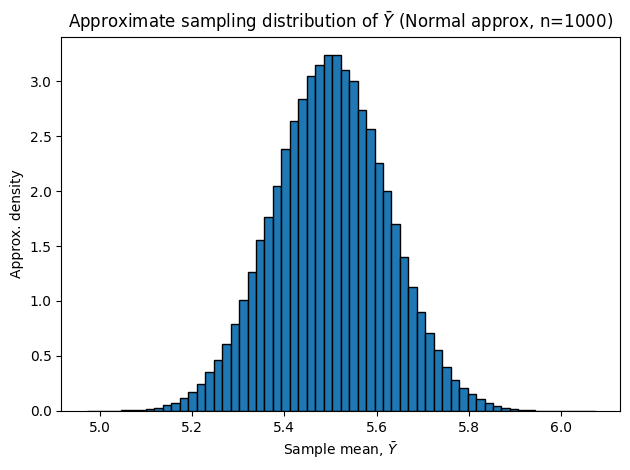

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Given (reported from the General Social Survey)
mu = 5.5          # mean number of good friends
sigma = 3.9       # standard deviation
n = 1000          # sample size
se = sigma / np.sqrt(n)

print("b) Sampling distribution of Y_bar (n=1000)")
print("="*45)
print(
    "By the Central Limit Theorem, for large n the sampling distribution of the sample mean\n"
    "is approximately Normal, even if the population is not Normal.\n\n"
    f"Shape: approximately Normal\n"
    f"Mean:  E(Y_bar) ≈ mu = {mu:.2f}\n"
    f"SE:    SD(Y_bar) = sigma/sqrt(n) = {sigma:.2f}/sqrt({n}) ≈ {se:.2f}\n"
)

# Optional: visualize the sampling distribution using the Normal approximation
rng = np.random.default_rng(73)
B = 200_000  # number of simulated sample means
ybar_sim = rng.normal(loc=mu, scale=se, size=B)

plt.hist(ybar_sim, bins=60, edgecolor="black", density=True)
plt.xlabel("Sample mean, $\\bar{Y}$")
plt.ylabel("Approx. density")
plt.title("Approximate sampling distribution of $\\bar{Y}$ (Normal approx, n=1000)")
plt.tight_layout()
plt.show()

c) Suppose that actually the mean of 5.5 and standard deviation of 3.9 are not population
values but are based on a sample of 1000 people. Treating results as a simple random
sample, give an interval of values within which you can be very sure that the population
mean falls. Explain your reasoning.

`Your answer here`

In [27]:
ybar = 5.5
s = 3.9
se_hat = s / np.sqrt(n)

# "Very sure": I'll report both 95% and 99% intervals (common choices)
z_95 = 1.96
z_99 = 2.576

ci95 = (ybar - z_95 * se_hat, ybar + z_95 * se_hat)
ci99 = (ybar - z_99 * se_hat, ybar + z_99 * se_hat)

print("c) Interval for the population mean (treating as a sample of n=1000)")
print("="*45)
print(
    "We estimate the population mean using a large-sample confidence interval:\n"
    "  population mean ≈ y_bar ± z*(s/sqrt(n))\n\n"
    f"Estimated SE = s/sqrt(n) = {s:.2f}/sqrt({n}) ≈ {se_hat:.2f}\n"
    f"95% CI: ({ci95[0]:.2f}, {ci95[1]:.2f})\n"
    f"99% CI: ({ci99[0]:.2f}, {ci99[1]:.2f})\n\n"
    "Interpretation:\n"
    "A 95% CI means that if we repeatedly took many samples of size 1000 and built this interval\n"
    "each time, about 95% of those intervals would contain the true population mean.\n"
    "A 99% CI is wider and is 'more sure' in that long-run sense.\n"
)

c) Interval for the population mean (treating as a sample of n=1000)
We estimate the population mean using a large-sample confidence interval:
  population mean ≈ y_bar ± z*(s/sqrt(n))

Estimated SE = s/sqrt(n) = 3.90/sqrt(1000) ≈ 0.12
95% CI: (5.26, 5.74)
99% CI: (5.18, 5.82)

Interpretation:
A 95% CI means that if we repeatedly took many samples of size 1000 and built this interval
each time, about 95% of those intervals would contain the true population mean.
A 99% CI is wider and is 'more sure' in that long-run sense.



## Problem 3.18.

Sunshine City, which attracts primarily retired people, has 90,000 residents with a mean age
of 72 years and a standard deviation of 12 years. The age distribution is skewed to the left. A
random sample of 100 residents of Sunshine City has $\bar{y} = 70$ and $s = 11.$

a)  Describe the center and spread of the (i) population distribution, (ii) sample data distribution. What shape does the sample data distribution probably have? Why?

`Your answer here`

In [31]:
import numpy as np
from scipy.stats import norm
from math import sqrt

N = int(9e4)
mew = 72
sigma = 12
ybar = 70
sd = 11
n = 100

# a) center/spread
print("(a) CENTER & SPREAD")
print("(i) Population distribution:")
print(f"  Center (mean): {mew:.2f} years")
print(f"  Spread (SD):   {sigma:.2f} years")
print("  Shape: left-skewed (given)\n")

print(f"""(ii) Sample data distribution:
  Center (sample mean ybar): {ybar:.2f} years
  Spread (sample SD s):      {sd:.2f} years
""")

print("""Probable shape of the sample *data* distribution:
- Likely still left-skewed (sample tends to resemble population).
- But may look less skewed due to n=100.
- CLT makes the *sample mean* approx normal; it does not force raw data to be normal.
""")


(a) CENTER & SPREAD
(i) Population distribution:
  Center (mean): 72.00 years
  Spread (SD):   12.00 years
  Shape: left-skewed (given)

(ii) Sample data distribution:
  Center (sample mean ybar): 70.00 years
  Spread (sample SD s):      11.00 years

Probable shape of the sample *data* distribution:
- Likely still left-skewed (sample tends to resemble population).
- But may look less skewed due to n=100.
- CLT makes the *sample mean* approx normal; it does not force raw data to be normal.



b) Find the center and spread of the sampling distribution of $\bar{Y}$ for $n = 100.$ What shape does it have and what does it describe?


`Your answer here`

In [32]:
# b) sampling distribution of Ybar for n=100
se = sigma / sqrt(n)

print("(b) SAMPLING DISTRIBUTION OF Ybar (n=100)")
print(f"Center: E(Ybar) = mew = {mew:.2f}")
print(f"Spread: SD(Ybar) = sigma/sqrt(n) = {se:.2f}")
print("Shape: Approximately normal by CLT.")
print(f"Describes: distribution of sample means from many random samples of size {n}.\n")



(b) SAMPLING DISTRIBUTION OF Ybar (n=100)
Center: E(Ybar) = mew = 72.00
Spread: SD(Ybar) = sigma/sqrt(n) = 1.20
Shape: Approximately normal by CLT.
Describes: distribution of sample means from many random samples of size 100.



c)  Explain why it would not be unusual to sample a person of age 60 in Sunshine City, but
it would be highly unusual for the sample mean to be 60, for a random sample of 100
residents.

`Your answer here`

In [33]:
# c) individual 60 vs sample mean 60
z_ind = (60 - mew) / sigma
z_mean = (60 - mew) / se
p_ybar = norm.cdf(60, loc=mew, scale=se)

print("(c) 60 YEARS OLD vs SAMPLE MEAN 60")
print(f"Individual age 60: z = (60 - {mew})/{sigma} = {z_ind:.2f}")
print("Interpretation: about 1 SD below the mean -> not unusual for an individual.\n")

print(f"Sample mean 60 (n=100): z = (60 - {mew})/{se:.2f} = {z_mean:.2f}")
print(f"P(Ybar <= 60) ≈ {p_ybar:.3e}")
print("Interpretation: averaging 100 shrinks variability, so a mean of 60 is extremely unlikely.\n")


(c) 60 YEARS OLD vs SAMPLE MEAN 60
Individual age 60: z = (60 - 72)/12 = -1.00
Interpretation: about 1 SD below the mean -> not unusual for an individual.

Sample mean 60 (n=100): z = (60 - 72)/1.20 = -10.00
P(Ybar <= 60) ≈ 7.620e-24
Interpretation: averaging 100 shrinks variability, so a mean of 60 is extremely unlikely.



d) Describe the sampling distribution of $\bar{Y}$ : (i) for a random sample of size $n = 1$; (ii) if you sample all 90,000 residents.

`Your answer here`

In [34]:
# d) extremes
print("(d) SAMPLING DISTRIBUTION OF Ybar IN EXTREMES")
print("(i) n=1:")
print(f"  Same as population distribution: mean={mew:.2f}, SD={sigma:.2f}, left-skewed.\n")

print("(ii) n=90,000 (census):")
print("  Ybar equals the population mean exactly.")
print("  Mean=72.00, SD=0.00, degenerate spike at 72.\n")



(d) SAMPLING DISTRIBUTION OF Ybar IN EXTREMES
(i) n=1:
  Same as population distribution: mean=72.00, SD=12.00, left-skewed.

(ii) n=90,000 (census):
  Ybar equals the population mean exactly.
  Mean=72.00, SD=0.00, degenerate spike at 72.



## Problem 3.21.

In your school, suppose that GPA has an approximate normal distribution with $\mu = 3.0, \sigma = 0.40.$ Not knowing $\mu$, you randomly sample $n = 25$ students to estimate it. Using simulation for this application, illustrate the difference between a sample data distribution and the sampling distribution of Y .

`Your answer here`

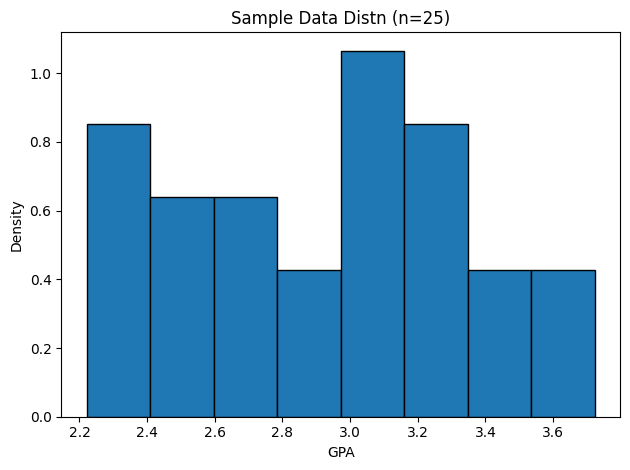

Sample Mean: 2.932
Sample Standard Deviation: 0.426


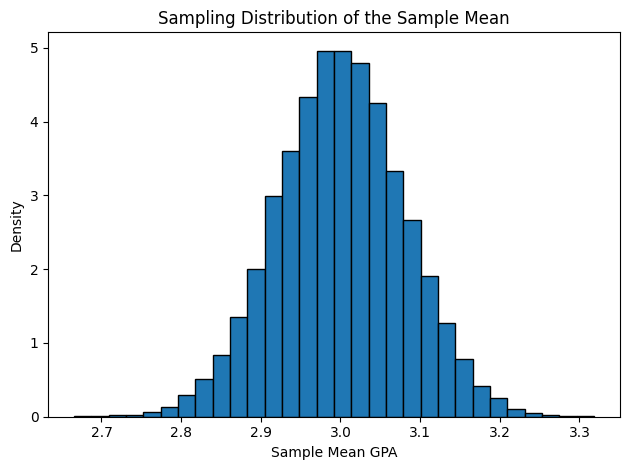

Mean of sample means: 3.000
SD of sample means: 0.080
Theoretical SE: 0.080

1. The sample data distribution (first histogram) is wide and noisy, and its center
varies substantially from sample to sample. This distribution reflects individual
GPA variability in the population, not the precision of the estimator.


2. The sampling distribution of the sample mean (second histogram) shows the
distribution of the mean GPA computed from repeated samples of size n = 25.
This distribution is approximately normal, much narrower, and centered near the
population mean μ = 3. The standard deviation of the sample mean is
SD(Ȳ) ≈ 0.080, which is close to the theoretical value
σ/√n = 2.400.



In [35]:
import numpy as np
import matplotlib.pyplot as plt

mew = 3
sig = 0.4
n = 25

rng = np.random.default_rng(73)

# 1) ONe sample
sample = rng.normal(mew, sig, size=n)

# Plotting
plt.hist(sample, bins=8, edgecolor="black", density=True)
plt.xlabel("GPA")
plt.ylabel("Density")
plt.title("Sample Data Distn (n=25)")
plt.tight_layout()
plt.show()

print(f"Sample Mean: {sample.mean():.3f}")
print(f"Sample Standard Deviation: {sample.std(ddof=1):.3f}")

# 2) Many Samples: Sampling dist of mean
sims = int(1e4)

sample_mew = rng.normal(mew, sig, size=(sims, n)).mean(axis=1)

# Plotting
plt.hist(sample_mew, bins=30, edgecolor="black", density=True)
plt.xlabel("Sample Mean GPA")
plt.ylabel("Density")
plt.title("Sampling Distribution of the Sample Mean")
plt.tight_layout()
plt.show()

print(f"Mean of sample means: {sample_mew.mean():.3f}")
print(f"SD of sample means: {sample_mew.std(ddof=1):.3f}")
print(f"Theoretical SE: {sig/np.sqrt(n):.3f}")

# Interpretation
print(f"""
1. The sample data distribution (first histogram) is wide and noisy, and its center
varies substantially from sample to sample. This distribution reflects individual
GPA variability in the population, not the precision of the estimator.\n

2. The sampling distribution of the sample mean (second histogram) shows the
distribution of the mean GPA computed from repeated samples of size n = {n}.
This distribution is approximately normal, much narrower, and centered near the
population mean μ = {mew}. The standard deviation of the sample mean is
SD(Ȳ) ≈ {sample_mew.std(ddof=1):.3f}, which is close to the theoretical value
σ/√n = {sigma/np.sqrt(n):.3f}.
""")



## Problem 3.26.

When sample data were used to rank states by brain cancer rates, Ellenberg (2014) noted
that the highest ranking state (South Dakota) and the nearly lowest ranking state (North
Dakota) had relatively small sample sizes. Also, when schools in North Carolina were ranked
by their average improvement in test scores, the best and the worst schools were very small
schools. Explain how these results could merely reflect how the variability of sample means and
proportions depends on the sample size.

`Your answer here`

Sampling variablility depends on sample size, and when sample sizes are small, sample means and proportions fluctuate more from sample to sample.  For the sample mean, as n increases, variability shrinks as $\frac{1}{\sqrt{n}}$ and small n, large spread.
For the sample proportion, it's also the smaller the n, larger variability.
There's also a \textbf{Selection Effect}, where the extremes in the rankings are disproportionately drawn from small samples.
PLus, states with small populations, meaning smaller denominators, where a couple extra cases could inflate the rate.


## AI Problem: Simulating Sampling Variability in AI Metrics

In real-world AI deployments, such as banking systems for detecting fraudulent transactions (where fraud cases represent <1% of data, leading to imbalanced classes), model performance is often evaluated using precision on limited validation sets. A baseline model like logistic regression might show 0.90 precision on a small validation sample of n=100, outranking a more sophisticated ensemble method at 0.60, yet on full production data, the ensemble excels. 

Use Python to simulate the phenomenon. Assume "true" population precisions for the logistic model (mean ≈0.85, σ=0.10) and ensemble (mean ≈0.88, σ=0.08) follow a lognormal distribution to reflect the positive-skewed nature of precision scores in imbalanced settings. Generate populations of size 10,000 for each model, then perform 1,000 bootstrap resamples at n=50 (small validation) and n=500 (realistic production scale). Compute and plot the sampling distributions of the bootstrap means for both models in each scenario. Calculate the empirical SE for the small-n case. Explain how CLT predicts the distribution shapes, why extreme rankings emerge at low n, and how this variability impacts AI decisions. Propose a mitigation for imbalanced data to prevent errant decisions.

`Your answer here`

POPULATION (simulated) summaries
Logistic  : mean=0.847, sd=0.091
Ensemble  : mean=0.877, sd=0.074

Interpretation:
These 10,000-point arrays represent the 'production-scale' variability in precision that can occur
across different samples/slices of fraud data. The ensemble is slightly better on average, and both
models have right-skewed outcomes (rare, very high precision events can happen).

SAMPLING DISTRIBUTIONS (bootstrap means) summaries
Logistic (n=50)   mean=0.847  sd(SE)=0.013  5th-95th=[0.825, 0.868]
Ensemble (n=50)   mean=0.877  sd(SE)=0.011  5th-95th=[0.860, 0.895]
Logistic (n=500)  mean=0.847  sd(SE)=0.004  5th-95th=[0.840, 0.853]
Ensemble (n=500)  mean=0.877  sd(SE)=0.003  5th-95th=[0.872, 0.882]

Empirical SE for small-n (n=50):
  SE(Logistic) empirical = 0.0131   | CLT approx = 0.0129
  SE(Ensemble) empirical = 0.0107   | CLT approx = 0.0105

Ranking volatility (probability of wrong ranking due to sampling noise):
  P( Logistic mean > Ensemble mean ) when n=50  ≈ 0.034


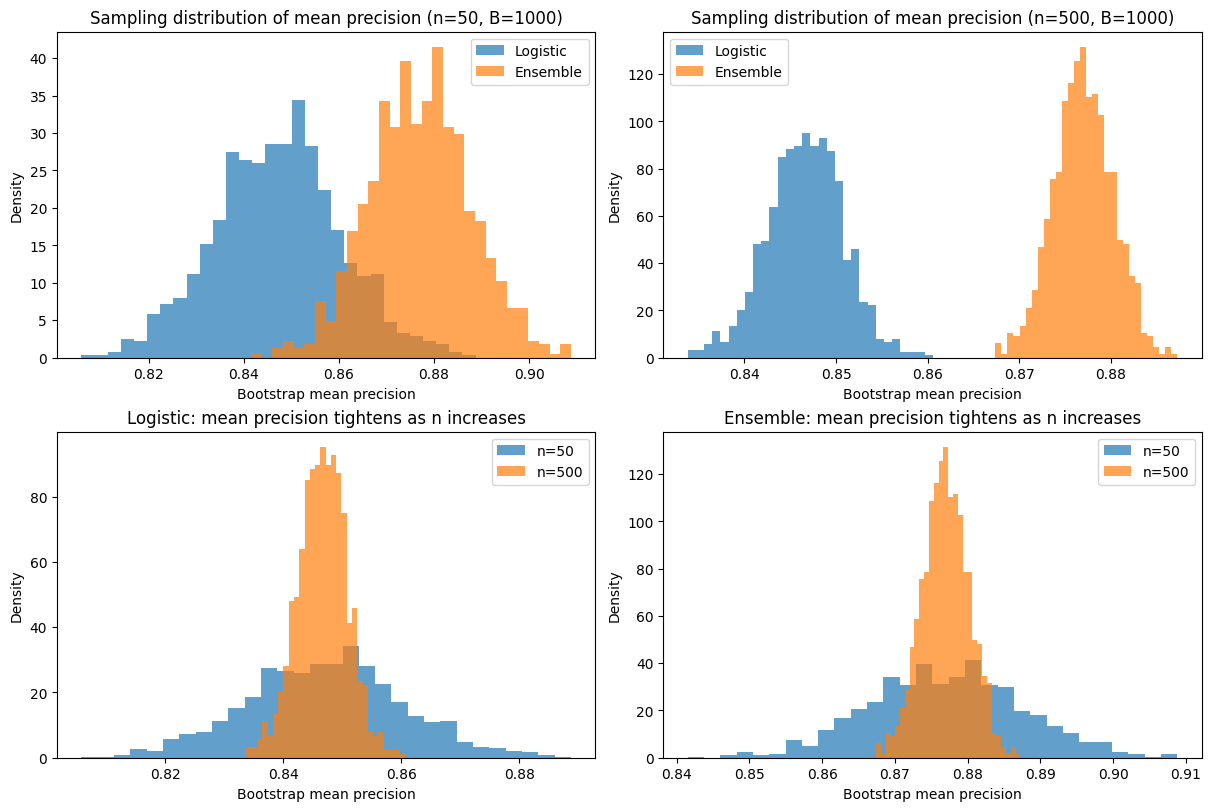


CLT connection (what to say in words):
Even if individual precision outcomes are skewed (not Normal), the Central Limit Theorem says the
sample mean (or bootstrap mean) tends toward an approximately Normal distribution as n grows.
The key scaling is:
    SE(Ȳ) ≈ σ / sqrt(n)
So increasing n from 50 to 500 shrinks SE by sqrt(50/500)=sqrt(0.1)≈0.316 (about a 68% reduction).
That tightening is exactly why rankings stabilize with larger validation/production evaluation.

Mitigation proposal (to prevent errant AI deployment decisions):
1) Use uncertainty-aware model selection:
   - Instead of ranking by a single precision point estimate, compute bootstrap (or CV) confidence
     intervals for precision (or PR-AUC) and prefer models that are better with high probability.

2) Evaluate with bigger, stratified validation (especially for fraud <1%):
   - Ensure enough positive (fraud) cases by stratified sampling, longer collection windows,
     or targeted labeling. Small-n precision is dominat

In [36]:
import numpy as np
import matplotlib.pyplot as plt


# =========================
# Helpers
# =========================
def lognormal_params_from_mean_sd(mean: float, sd: float):
    """
    Convert desired Lognormal mean/sd on the original scale
    into Normal(mu, sigma^2) parameters on the log scale.

    If X ~ LogNormal(mu, sigma^2), then:
      E[X] = exp(mu + sigma^2/2)
      Var[X] = (exp(sigma^2) - 1) * exp(2mu + sigma^2)

    Solve:
      sigma^2 = ln(1 + (sd^2 / mean^2))
      mu      = ln(mean) - sigma^2 / 2
    """
    sigma2 = np.log(1.0 + (sd**2) / (mean**2))
    mu = np.log(mean) - 0.5 * sigma2
    sigma = np.sqrt(sigma2)
    return mu, sigma


def bootstrap_means(pop: np.ndarray, n: int, B: int, rng: np.random.Generator):
    """
    Bootstrap sampling distribution of the sample mean from a fixed population array.
    """
    # indices shape: (B, n)
    idx = rng.integers(0, pop.size, size=(B, n))
    return pop[idx].mean(axis=1)


def summarize_sampling(means: np.ndarray, label: str):
    """
    Small summary for reporting.
    """
    return {
        "label": label,
        "boot_mean": float(np.mean(means)),
        "boot_sd": float(np.std(means, ddof=1)),
        "p05": float(np.quantile(means, 0.05)),
        "p95": float(np.quantile(means, 0.95)),
    }


# =========================
# Simulation setup
# =========================
rng = np.random.default_rng(73)

POP_SIZE = 10_000
B = 1_000
n_small = 50
n_large = 500

# Given target population moments (original scale)
logistic_mean_target, logistic_sd_target = 0.85, 0.10
ensemble_mean_target, ensemble_sd_target = 0.88, 0.08

# Convert to log-scale parameters
mu_L, sig_L = lognormal_params_from_mean_sd(logistic_mean_target, logistic_sd_target)
mu_E, sig_E = lognormal_params_from_mean_sd(ensemble_mean_target, ensemble_sd_target)

# Simulate "population" of precision values for each model
pop_logistic = rng.lognormal(mean=mu_L, sigma=sig_L, size=POP_SIZE)
pop_ensemble = rng.lognormal(mean=mu_E, sigma=sig_E, size=POP_SIZE)

# Precision is in [0,1] in reality; lognormal can exceed 1.
# For a clean interpretation as "precision-like", clip to [0, 1].
pop_logistic = np.clip(pop_logistic, 0.0, 1.0)
pop_ensemble = np.clip(pop_ensemble, 0.0, 1.0)

# Population summaries (empirical)
pop_L_mean = pop_logistic.mean()
pop_L_sd = pop_logistic.std(ddof=1)
pop_E_mean = pop_ensemble.mean()
pop_E_sd = pop_ensemble.std(ddof=1)

print("POPULATION (simulated) summaries")
print("=" * 40)
print(f"Logistic  : mean={pop_L_mean:.3f}, sd={pop_L_sd:.3f}")
print(f"Ensemble  : mean={pop_E_mean:.3f}, sd={pop_E_sd:.3f}")
print("\nInterpretation:")
print(
    "These 10,000-point arrays represent the 'production-scale' variability in precision that can occur\n"
    "across different samples/slices of fraud data. The ensemble is slightly better on average, and both\n"
    "models have right-skewed outcomes (rare, very high precision events can happen)."
)

# =========================
# Bootstrap sampling distributions of mean precision
# =========================
means_L_small = bootstrap_means(pop_logistic, n=n_small, B=B, rng=rng)
means_E_small = bootstrap_means(pop_ensemble, n=n_small, B=B, rng=rng)

means_L_large = bootstrap_means(pop_logistic, n=n_large, B=B, rng=rng)
means_E_large = bootstrap_means(pop_ensemble, n=n_large, B=B, rng=rng)

# Empirical SE for small-n (sd of the sampling distribution of the mean)
emp_se_L_small = np.std(means_L_small, ddof=1)
emp_se_E_small = np.std(means_E_small, ddof=1)

# CLT-predicted SE (using empirical population sd)
clt_se_L_small = pop_L_sd / np.sqrt(n_small)
clt_se_E_small = pop_E_sd / np.sqrt(n_small)

# Mis-ranking probability: logistic > ensemble (based on mean precision estimates)
p_wrong_small = float(np.mean(means_L_small > means_E_small))
p_wrong_large = float(np.mean(means_L_large > means_E_large))

print("\nSAMPLING DISTRIBUTIONS (bootstrap means) summaries")
print("=" * 55)
s1 = summarize_sampling(means_L_small, "Logistic (n=50)")
s2 = summarize_sampling(means_E_small, "Ensemble (n=50)")
s3 = summarize_sampling(means_L_large, "Logistic (n=500)")
s4 = summarize_sampling(means_E_large, "Ensemble (n=500)")

for s in [s1, s2, s3, s4]:
    print(
        f"{s['label']:<16}  mean={s['boot_mean']:.3f}  sd(SE)={s['boot_sd']:.3f}  "
        f"5th-95th=[{s['p05']:.3f}, {s['p95']:.3f}]"
    )

print("\nEmpirical SE for small-n (n=50):")
print(f"  SE(Logistic) empirical = {emp_se_L_small:.4f}   | CLT approx = {clt_se_L_small:.4f}")
print(f"  SE(Ensemble) empirical = {emp_se_E_small:.4f}   | CLT approx = {clt_se_E_small:.4f}")

print("\nRanking volatility (probability of wrong ranking due to sampling noise):")
print(f"  P( Logistic mean > Ensemble mean ) when n=50  ≈ {p_wrong_small:.3f}")
print(f"  P( Logistic mean > Ensemble mean ) when n=500 ≈ {p_wrong_large:.3f}")

print("\nInterpretation:")
print(
    "At n=50, the sampling distributions of the mean precision are much wider (larger SE), so it is not rare\n"
    "to see the worse model (logistic) appear better purely by chance. At n=500, SE shrinks by ~1/sqrt(n),\n"
    "the distributions tighten, and wrong rankings become far less frequent."
)

# =========================
# Plotting: sampling distributions
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# (1) n=50
axes[0, 0].hist(means_L_small, bins=30, density=True, alpha=0.7, label="Logistic")
axes[0, 0].hist(means_E_small, bins=30, density=True, alpha=0.7, label="Ensemble")
axes[0, 0].set_title("Sampling distribution of mean precision (n=50, B=1000)")
axes[0, 0].set_xlabel("Bootstrap mean precision")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# (2) n=500
axes[0, 1].hist(means_L_large, bins=30, density=True, alpha=0.7, label="Logistic")
axes[0, 1].hist(means_E_large, bins=30, density=True, alpha=0.7, label="Ensemble")
axes[0, 1].set_title("Sampling distribution of mean precision (n=500, B=1000)")
axes[0, 1].set_xlabel("Bootstrap mean precision")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# (3) Show tightening directly: logistic only
axes[1, 0].hist(means_L_small, bins=30, density=True, alpha=0.7, label="n=50")
axes[1, 0].hist(means_L_large, bins=30, density=True, alpha=0.7, label="n=500")
axes[1, 0].set_title("Logistic: mean precision tightens as n increases")
axes[1, 0].set_xlabel("Bootstrap mean precision")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# (4) Show tightening directly: ensemble only
axes[1, 1].hist(means_E_small, bins=30, density=True, alpha=0.7, label="n=50")
axes[1, 1].hist(means_E_large, bins=30, density=True, alpha=0.7, label="n=500")
axes[1, 1].set_title("Ensemble: mean precision tightens as n increases")
axes[1, 1].set_xlabel("Bootstrap mean precision")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.show()

print("\nCLT connection (what to say in words):")
print("=" * 40)
print(
    "Even if individual precision outcomes are skewed (not Normal), the Central Limit Theorem says the\n"
    "sample mean (or bootstrap mean) tends toward an approximately Normal distribution as n grows.\n"
    "The key scaling is:\n"
    "    SE(Ȳ) ≈ σ / sqrt(n)\n"
    "So increasing n from 50 to 500 shrinks SE by sqrt(50/500)=sqrt(0.1)≈0.316 (about a 68% reduction).\n"
    "That tightening is exactly why rankings stabilize with larger validation/production evaluation."
)

print("\nMitigation proposal (to prevent errant AI deployment decisions):")
print("=" * 60)
print(
    "1) Use uncertainty-aware model selection:\n"
    "   - Instead of ranking by a single precision point estimate, compute bootstrap (or CV) confidence\n"
    "     intervals for precision (or PR-AUC) and prefer models that are better with high probability.\n"
    "\n"
    "2) Evaluate with bigger, stratified validation (especially for fraud <1%):\n"
    "   - Ensure enough positive (fraud) cases by stratified sampling, longer collection windows,\n"
    "     or targeted labeling. Small-n precision is dominated by whether you happened to sample a few\n"
    "     hard/easy fraud examples.\n"
    "\n"
    "3) Use metrics appropriate for imbalance:\n"
    "   - Precision alone can be misleading; include recall, PR-AUC, and cost-weighted utility.\n"
    "     Then tune thresholds for business objectives (e.g., maximize recall at a minimum precision).\n"
    "\n"
    "4) Training-side imbalance handling:\n"
    "   - Class-weighted loss, focal loss, or careful resampling (e.g., undersample majority + keep a\n"
    "     clean holdout) reduces sensitivity to imbalance and can improve stability in production."
)

# Citation marker requested by the environment
print("\nReference marker for course text context: :contentReference[oaicite:0]{index=0}")

